# Neural Network Results

This notebook summarizes the performance of the trained regression network used in this project and compares its inferred initial conditions against the reference grid and the subsequent numerical integrations.

The notebook assumes the trained artifacts are available under `outputs/` inside this repository.


In [1]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
import importlib

import source.main_functions as ft
importlib.reload(ft)


current_dir = Path.cwd().resolve()
if (current_dir / 'source').exists():
    repo_root = current_dir
elif (current_dir.parent / 'source').exists():
    repo_root = current_dir.parent
else:
    repo_root = current_dir

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

name_NN = 'NN_z_approx_32_trained_dense_v2'
name_grid = 'grid_z_approx_32_validation_data'
path_NN_folder = repo_root / 'outputs' / 'neural_networks' / name_NN
path_grid = repo_root / 'outputs' / 'grids' / name_grid / f'grilla_results_{name_grid}.csv'
path_validation_set_NN = repo_root / 'outputs' / 'neural_networks' / name_NN / f'y_val_{name_NN}.csv'

paths = {
    'model': path_NN_folder / f'regression_model_{name_NN}.pth',
    'training_history': path_NN_folder / f'training_history_{name_NN}.csv',
    'final_metrics': path_NN_folder / f'final_metrics_{name_NN}.csv',
    'scaler_X': path_NN_folder / f'scaler_X_{name_NN}.pkl',
    'scaler_y': path_NN_folder / f'scaler_y_{name_NN}.pkl',
    'grid': path_grid,
    'validation_set': path_validation_set_NN,
} #change the paths to the artifacts you want to use if you are not clonning this repo

missing = [name for name, path in paths.items() if not path.exists()]
if missing:
    raise FileNotFoundError(f'Missing required artifacts: {missing}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


## Load the trained network

We load the best checkpoint together with the input and output scalers used during training so that all predictions are evaluated in the same normalized space as the original model.


In [2]:
model, scaler_X, scaler_y, model_config = ft.load_trained_regression_nn(name_NN, map_location=device)
model = model.to(device)

training_history = pd.read_csv(paths['training_history'])
final_metrics = pd.read_csv(paths['final_metrics'])

display(final_metrics)
if model_config:
    display(pd.DataFrame([model_config]))


,Target,MAE,RMSE,R2
0,delta_m,0.012911,0.018212,1.0
1,delta_prime_m,0.406930,0.575923,1.0


,activation,hidden_layers,dropout,use_layernorm
0,tanh,"[192, 192, 192, 128, 64]",0.0,False


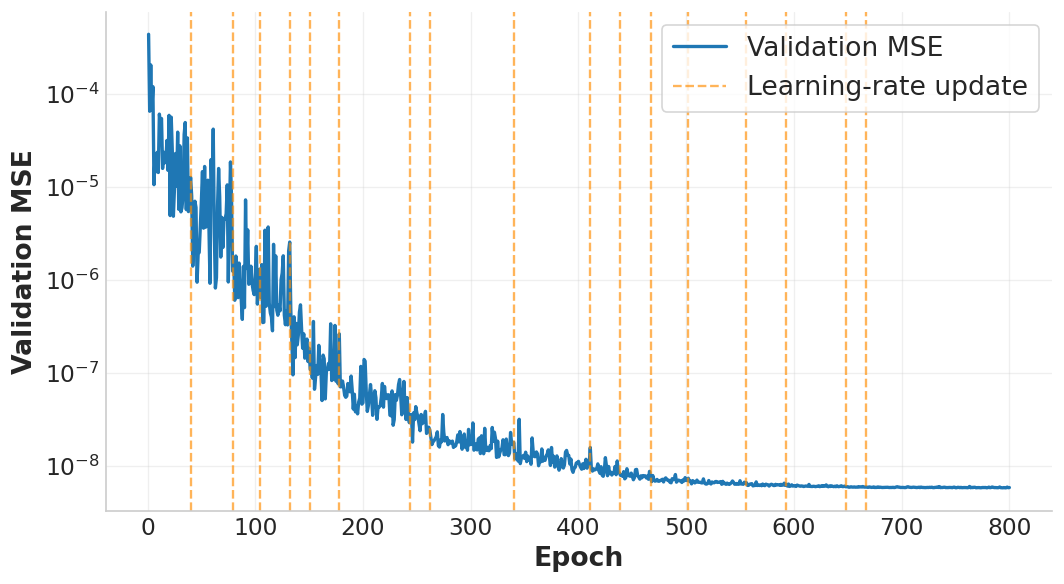

In [3]:
val_mse = training_history['Val_MSE'].to_numpy()
learning_rate = training_history['Learning_Rate'].to_numpy()
lr_drop_epochs = np.flatnonzero(np.diff(learning_rate) < 0) + 2

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(training_history['Epoch'], val_mse, color='tab:blue', linewidth=2, label='Validation MSE')
ax.set_yscale('log')
ax.set_xlabel('Epoch', fontsize=16, fontweight='bold')
ax.set_ylabel('Validation MSE', fontsize=16, fontweight='bold')
ax.grid(alpha=0.3)

for idx, epoch in enumerate(lr_drop_epochs):
    ax.axvline(
        x=epoch,
        color='darkorange',
        linestyle='--',
        linewidth=1.4,
        alpha=0.65,
        label='Learning-rate update' if idx == 0 else None,
    )

ax.legend(frameon=True, loc='best', fontsize=16)
#bigger ticks
ax.tick_params(axis='both', which='major', labelsize=14)
# ax.set_title('Training history', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Network vs grid


### Network vs validation grid

The next block evaluates the network on the chosen validation grid, which was generated at unseen midpoint cosmologies inside the training domain.


In [4]:
features = ['a', 'k h', 'h', 'Omega_m']
targets = ['delta_m', 'delta_prime_m']

df_grid = pd.read_csv(paths['grid'])
mask = (
    (df_grid['k h'] <= 0.2)
    & (df_grid['a'] < 0.0345)
    & (df_grid['h'] > 0.622)
    & (df_grid['h'] < 0.758)
    & (df_grid['Omega_m'] > 0.1)
    & (df_grid['Omega_m'] < 0.45)

)

if 'k_horizon' in df_grid.columns:
    mask &= df_grid['k h'] > 1.2* df_grid['k_horizon']
    

df_eval = df_grid.loc[mask].copy().reset_index(drop=True)
X = df_eval[features].to_numpy()
y_true = df_eval[targets].to_numpy()

X_scaled = scaler_X.transform(X)
X_tensor = torch.tensor(X_scaled, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred_scaled = model(X_tensor).cpu().numpy()
y_pred = scaler_y.inverse_transform(y_pred_scaled)

def percent_error(predicted, reference):
    reference = np.asarray(reference)
    predicted = np.asarray(predicted)
    return 100.0 * np.abs(predicted - reference) / np.abs(reference)

df_report = df_eval.copy()
for idx, target in enumerate(targets):
    df_report[f'pred_{target}'] = y_pred[:, idx]
    df_report[f'abs_error_{target}'] = np.abs(y_pred[:, idx] - y_true[:, idx])
    df_report[f'rel_error_{target} (%)'] = percent_error(y_pred[:, idx], y_true[:, idx])

summary = pd.DataFrame(
    {
        'mean (%)': [df_report[f'rel_error_{t} (%)'].mean() for t in targets],
        'median (%)': [df_report[f'rel_error_{t} (%)'].median() for t in targets],
        'p90 (%)': [df_report[f'rel_error_{t} (%)'].quantile(0.90) for t in targets],
        'p99 (%)': [df_report[f'rel_error_{t} (%)'].quantile(0.99) for t in targets],
        'max (%)': [df_report[f'rel_error_{t} (%)'].max() for t in targets],
        'share > 1%': [float((df_report[f'rel_error_{t} (%)'] > 1.0).mean()) for t in targets],
    },
    index=targets,
)

#compute MAE and RMS for the evaluated grid
mae = [np.mean(np.abs(y_pred[:, i] - y_true[:, i])) for i in range(len(targets))]
rms = [np.sqrt(np.mean((y_pred[:, i] - y_true[:, i]) ** 2)) for i in range(len(targets))]

summary['MAE'] = mae
summary['RMS'] = rms

display(summary)
display(
    df_report.sort_values('rel_error_delta_m (%)', ascending=False)
    .head(5)
    .reset_index(drop=True)
)

print(f"Total number of evaluated points: {len(df_report)}")


,mean (%),median (%),p90 (%),p99 (%),max (%),share > 1%,MAE,RMS
delta_m,0.004301,0.002473,0.009747,0.030306,0.315927,0.0,0.011675,0.015837
delta_prime_m,0.004196,0.002479,0.009493,0.028134,0.490477,0.0,0.368194,0.501620


,a,k,k h,Omega_cdm,Omega_b,Omega_m,A_s,h,k_horizon,sigma8,...,delta_m,delta_prime_cdm,delta_prime_b,delta_prime_m,pred_delta_m,abs_error_delta_m,rel_error_delta_m (%),pred_delta_prime_m,abs_error_delta_prime_m,rel_error_delta_prime_m (%)
0,0.034003,0.017314,0.024805,0.100123,0.048677,0.1488,2.000000e-09,0.6980,0.004746,0.411578,...,-129.737758,-3780.170004,-3730.355443,-3763.874031,-129.327881,0.409877,0.315927,-3762.231934,1.642097,0.043628
1,0.034201,0.015568,0.024173,0.089323,0.048677,0.1380,2.000000e-09,0.6440,0.004581,0.342019,...,-118.915415,-3437.751213,-3388.860871,-3420.505907,-119.212250,0.296835,0.249618,-3437.282715,16.776808,0.490477
2,0.031131,0.016577,0.022560,0.164123,0.048677,0.2128,2.000000e-09,0.7348,0.005610,0.641379,...,-116.565588,-3706.639054,-3674.657211,-3699.323305,-116.333923,0.231665,0.198742,-3689.913574,9.409731,0.254364
3,0.029501,0.007417,0.011916,0.383323,0.048677,0.4320,2.000000e-09,0.6224,0.008049,0.913325,...,-28.914404,-943.199772,-941.482877,-943.006314,-28.958101,0.043697,0.151127,-942.787720,0.218594,0.023181
4,0.029505,0.007536,0.012061,0.396523,0.048677,0.4452,2.000000e-09,0.6248,0.008169,0.933571,...,-28.911895,-942.968285,-941.250858,-942.780505,-28.953096,0.041202,0.142508,-942.529907,0.250597,0.026581


Total number of evaluated points: 2674112


### Network vs validation set of the trianing grid

In [19]:
features = ['a', 'k h', 'h', 'Omega_m']
targets = ['delta_m', 'delta_prime_m']

df_grid = pd.read_csv(paths['validation_set'])
mask = (
    (df_grid['k h'] <= 0.2)
    & (df_grid['a'] < 0.0345)
    & (df_grid['h'] > 0.622)
    & (df_grid['h'] < 0.758)
    & (df_grid['Omega_m'] > 0.1)
    & (df_grid['Omega_m'] < 0.45)

)

if 'k_horizon' in df_grid.columns:
    mask &= df_grid['k h'] > df_grid['k_horizon']
else:
    df_grid['k_horizon'] = ft.k_horizon(
        a_ini = df_grid['a'].values, h = df_grid['h'].values, omega_m = df_grid['Omega_m'].values)
    mask &= df_grid['k h'] > df_grid['k_horizon']
    

df_eval = df_grid.loc[mask].copy().reset_index(drop=True)
X = df_eval[features].to_numpy()
y_true = df_eval[targets].to_numpy()

X_scaled = scaler_X.transform(X)
X_tensor = torch.tensor(X_scaled, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred_scaled = model(X_tensor).cpu().numpy()
y_pred = scaler_y.inverse_transform(y_pred_scaled)

def percent_error(predicted, reference):
    reference = np.asarray(reference)
    predicted = np.asarray(predicted)
    return 100.0 * np.abs(predicted - reference) / np.abs(reference)

df_report = df_eval.copy()
for idx, target in enumerate(targets):
    df_report[f'pred_{target}'] = y_pred[:, idx]
    df_report[f'abs_error_{target}'] = np.abs(y_pred[:, idx] - y_true[:, idx])
    df_report[f'rel_error_{target} (%)'] = percent_error(y_pred[:, idx], y_true[:, idx])

summary = pd.DataFrame(
    {
        'mean (%)': [df_report[f'rel_error_{t} (%)'].mean() for t in targets],
        'median (%)': [df_report[f'rel_error_{t} (%)'].median() for t in targets],
        'p90 (%)': [df_report[f'rel_error_{t} (%)'].quantile(0.90) for t in targets],
        'p99 (%)': [df_report[f'rel_error_{t} (%)'].quantile(0.99) for t in targets],
        'max (%)': [df_report[f'rel_error_{t} (%)'].max() for t in targets],
        'share > 1%': [float((df_report[f'rel_error_{t} (%)'] > 1.0).mean()) for t in targets],
    },
    index=targets,
)

#compute MAE and RMS for the evaluated grid
mae = [np.mean(np.abs(y_pred[:, i] - y_true[:, i])) for i in range(len(targets))]
rms = [np.sqrt(np.mean((y_pred[:, i] - y_true[:, i]) ** 2)) for i in range(len(targets))]

summary['MAE'] = mae
summary['RMS'] = rms

display(summary)
display(
    df_report.sort_values('rel_error_delta_m (%)', ascending=False)
    .head(5)
    .reset_index(drop=True)
)

print(f"Total number of evaluated points: {len(df_report)}")


,mean (%),median (%),p90 (%),p99 (%),max (%),share > 1%,MAE,RMS
delta_m,0.004538,0.002514,0.010272,0.033838,0.151126,0.0,0.011580,0.015738
delta_prime_m,0.004501,0.002519,0.009988,0.033608,0.373671,0.0,0.365102,0.498478


,a,k h,h,Omega_m,delta_m,delta_prime_m,k_horizon,pred_delta_m,abs_error_delta_m,rel_error_delta_m (%),pred_delta_prime_m,abs_error_delta_prime_m,rel_error_delta_prime_m (%)
0,0.029501,0.011916,0.6224,0.4320,-28.914404,-943.00630,0.008054,-28.958101,0.043697,0.151126,-942.787720,0.218580,0.023179
1,0.033737,0.025079,0.7492,0.1540,-137.427600,-4025.13550,0.004510,-137.236298,0.191302,0.139202,-4020.143066,4.992434,0.124031
2,0.029516,0.011769,0.6224,0.4188,-28.958937,-944.03973,0.007929,-28.998232,0.039295,0.135692,-943.860962,0.178768,0.018937
3,0.033920,0.083931,0.6956,0.1032,-147.228300,-4269.06700,0.003701,-147.034637,0.193663,0.131539,-4260.466309,8.600691,0.201465
4,0.033725,0.025078,0.7504,0.1540,-137.530910,-4029.62060,0.004511,-137.351135,0.179775,0.130716,-4024.734863,4.885737,0.121246


Total number of evaluated points: 539035


## Single-point inference example

This compact example is useful for quickly checking the inferred initial conditions at a chosen point in parameter space.


In [33]:
sample_parameters = {
    'a': 0.03,
    'k h': 0.01,
    'h': 0.68,
    'Omega_m': 0.30,
}

X_single = np.array([[sample_parameters['a'], sample_parameters['k h'], sample_parameters['h'], sample_parameters['Omega_m']]])
X_single_scaled = scaler_X.transform(X_single)
X_single_tensor = torch.tensor(X_single_scaled, dtype=torch.float32, device=device)

with torch.no_grad():
    y_single_scaled = model(X_single_tensor).cpu().numpy()
y_single = scaler_y.inverse_transform(y_single_scaled)[0]

example_result = pd.DataFrame(
    {
        'quantity': ['delta_m', 'delta_prime_m'],
        'prediction': y_single,
    }
)
display(example_result)


,quantity,prediction
0,delta_m,-29.197203
1,delta_prime_m,-936.529297


## From network-predicted initial conditions to full numerical evolution

The following helper functions compare the network output with the reference grid, then use both sets of initial conditions to integrate the matter perturbation equation.


In [7]:
from matplotlib.lines import Line2D
from matplotlib.ticker import ScalarFormatter

def filter_grid_data(df, Omega_m=0.3, h=0.68, As=2e-9, kh=None, k=None, verbose=False):
    """    
    Since the grid is not continuous, this function filters the grid data to find the closest matching row based on the provided parameters. 
    If no exact match is found, it selects the nearest row based on a distance metric.
    Args:
        df (pd.DataFrame): The DataFrame containing the grid data.
        Omega_m (float): The target value for Omega_m.
        h (float): The target value for h.
        As (float, optional): The target value for A_s. Defaults to 2e-9.
        kh (float, optional): The target value for k h. If provided, it will filter for rows with k h >= kh. Defaults to None.
        k (float, optional): The target value for k. If provided, it will filter for rows with k >= k. Defaults to None.
        verbose (bool, optional): If True, prints information about the filtering process. Defaults to False.
    Returns:
        pd.DataFrame: A filtered DataFrame containing the closest matching row(s) based on the provided parameters.
    """
    
    filtered = df.copy()

    mask = (
        np.isclose(filtered['Omega_m'], Omega_m, rtol=0, atol=5e-3)
        & np.isclose(filtered['h'], h, rtol=0, atol=5e-3)
    )

    if 'A_s' in filtered.columns and As is not None:
        mask &= np.isclose(filtered['A_s'], As, rtol=0, atol=5e-11)

    filtered = filtered.loc[mask].copy()

    if filtered.empty:
        work = df.copy()
        d_om = np.abs(work['Omega_m'] - Omega_m) / max(abs(Omega_m), 1e-6)
        d_h = np.abs(work['h'] - h) / max(abs(h), 1e-6)
        if 'A_s' in work.columns and As is not None:
            d_as = np.abs(work['A_s'] - As) / max(abs(As), 1e-20)
        else:
            d_as = 0.0
        work['_dist'] = d_om + d_h + d_as
        filtered = work.loc[work['_dist'] == work['_dist'].min()].drop(columns=['_dist']).copy()
        if verbose and not filtered.empty:
            row0 = filtered.iloc[0]
            msg_as = f", A_s={row0['A_s']:.3e}" if 'A_s' in filtered.columns else ''
            print(
                'No exact parameter match was found. Using the nearest row: '
                f"Omega_m={row0['Omega_m']:.5f}, h={row0['h']:.5f}{msg_as}"
            )

    if filtered.empty:
        return filtered

    if k is not None and 'k' in filtered.columns:
        candidate = filtered[filtered['k'] >= k]
        if candidate.empty:
            idx = (filtered['k'] - k).abs().idxmin()
            filtered = filtered.loc[[idx]].copy()
            if verbose:
                print(f"No k >= {k}. Using the nearest k: {filtered.iloc[0]['k']:.6g}")
        else:
            selected_k = candidate['k'].min()
            filtered = filtered[filtered['k'] == selected_k].copy()

    if kh is not None and 'k h' in filtered.columns:
        candidate = filtered[filtered['k h'] >= kh]
        if candidate.empty:
            idx = (filtered['k h'] - kh).abs().idxmin()
            filtered = filtered.loc[[idx]].copy()
            if verbose:
                print(f"No k h >= {kh}. Using the nearest k h: {filtered.iloc[0]['k h']:.6g}")
        else:
            selected_kh = candidate['k h'].min()
            filtered = filtered[filtered['k h'] == selected_kh].copy()

    return filtered


def compare_nn_vs_grid(df, model, scaler_X, scaler_y, row_idx=None, custom_parameters=None, verbose=False):
    features = ['a', 'k h', 'h', 'Omega_m']
    targets = ['delta_m', 'delta_prime_m']

    if custom_parameters is not None:
        parameters = custom_parameters.copy()
    elif row_idx is not None:
        selected_row = df.iloc[row_idx]
        parameters = {feature: selected_row[feature] for feature in features}
        if 'A_s' in df.columns:
            parameters['A_s'] = selected_row['A_s']
    else:
        raise ValueError('Provide either row_idx or custom_parameters.')

    df_selected = filter_grid_data(
        df,
        Omega_m=parameters['Omega_m'],
        h=parameters['h'],
        As=parameters.get('A_s', None),
        kh=parameters['k h'],
        verbose=verbose,
    )

    if df_selected.empty:
        raise ValueError('No matching row could be found in the grid.')

    row = df_selected.iloc[0]
    used_parameters = {feature: row[feature] for feature in features}
    grid_results = row[targets].to_numpy(dtype=float)

    X_input = np.array([[used_parameters['a'], used_parameters['k h'], used_parameters['h'], used_parameters['Omega_m']]], dtype=float)
    X_input_scaled = scaler_X.transform(X_input)
    X_tensor = torch.tensor(X_input_scaled, dtype=torch.float32, device=device)

    with torch.no_grad():
        model.eval()
        nn_scaled = model(X_tensor).cpu().numpy()[0]
    nn_results = scaler_y.inverse_transform(nn_scaled.reshape(1, -1))[0]

    abs_diff = np.abs(nn_results - grid_results)
    rel_diff = 100.0 * abs_diff /np.abs(grid_results)

    if verbose:
        print('Requested parameters:', parameters)
        print('Used parameters:', used_parameters)
        print('Grid initial conditions:', grid_results)
        print('NN initial conditions:', nn_results)

    return {
        'parameters': used_parameters,
        'grid_results': grid_results,
        'nn_results': nn_results,
        'absolute_difference': abs_diff,
        'relative_difference': rel_diff,
        'grid_initial_conditions': {
            'delta_i': grid_results[0],
            'delta_prime_i': grid_results[1],
        },
        'nn_initial_conditions': {
            'delta_i': nn_results[0],
            'delta_prime_i': nn_results[1],
        },
        'filtered_grid': df_selected,
    }


In [9]:
custom_parameters = {
    'a': 0.02,
    'k h': 0.15,
    'h': 0.70,
    'Omega_m': 0.30,
}

comparison = compare_nn_vs_grid(
    df_eval,
    model,
    scaler_X,
    scaler_y,
    custom_parameters=custom_parameters,
    verbose=True,
)

comparison_table = pd.DataFrame(
    {
        'quantity': ['delta_m', 'delta_prime_m'],
        'grid': comparison['grid_results'],
        'network': comparison['nn_results'],
        'absolute_difference': comparison['absolute_difference'],
        'relative_difference (%)': comparison['relative_difference'],
    }
)
display(comparison_table)


Requested parameters: {'a': 0.02, 'k h': 0.15, 'h': 0.7, 'Omega_m': 0.3}
Used parameters: {'a': 0.03146096, 'k h': 0.1538602011494252, 'h': 0.6960000000000001, 'Omega_m': 0.2960000000000002}
Grid initial conditions: [  -665.41093972 -21016.36564823]
NN initial conditions: [  -665.4255 -21016.787 ]


,quantity,grid,network,absolute_difference,relative_difference (%)
0,delta_m,-665.410940,-665.425476,0.014536,0.002185
1,delta_prime_m,-21016.365648,-21016.787109,0.421461,0.002005


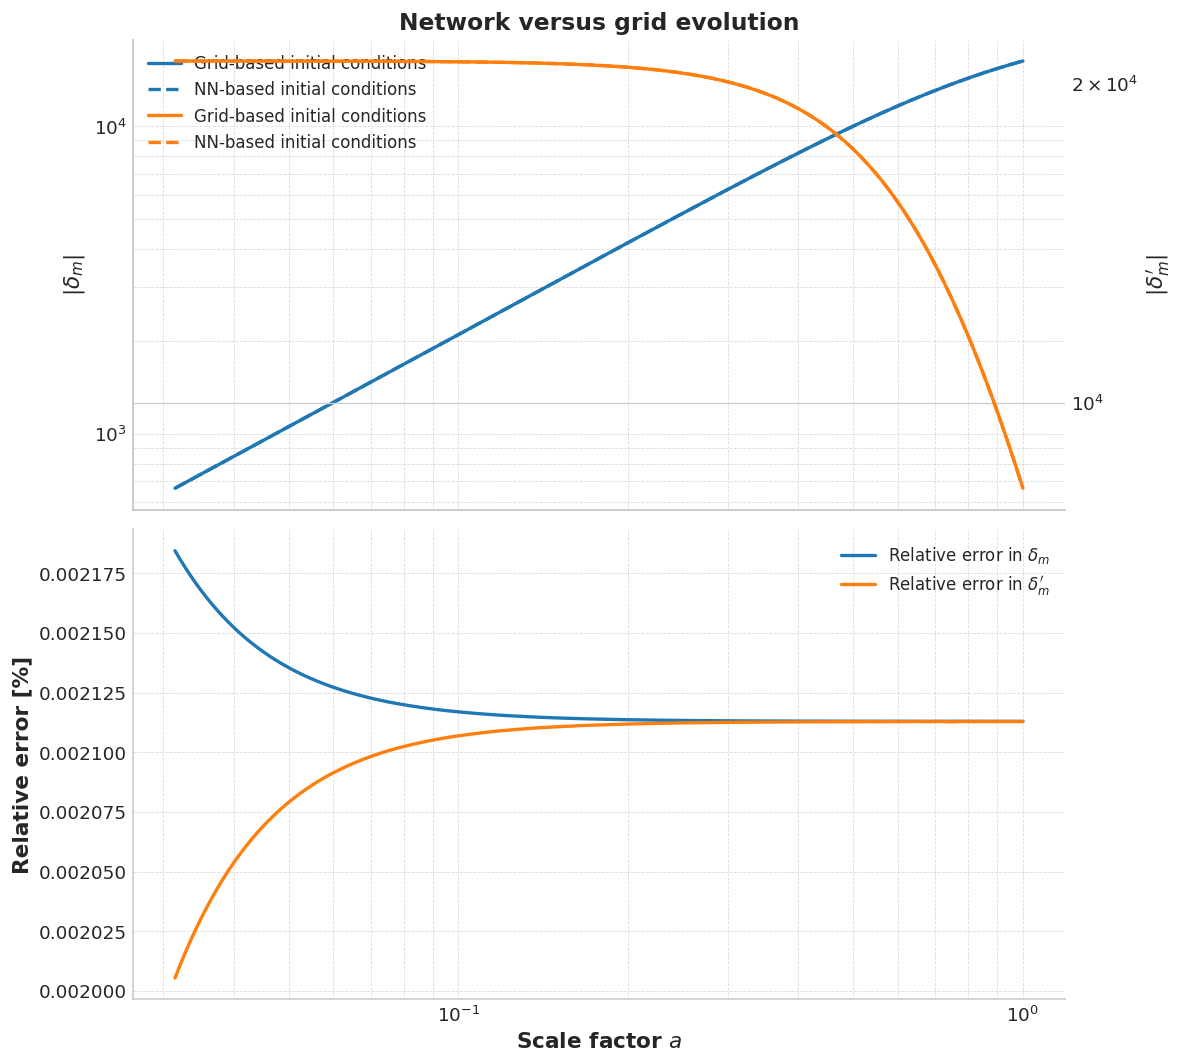

In [10]:
params = comparison['parameters']
grid_ic = comparison['grid_initial_conditions']
nn_ic = comparison['nn_initial_conditions']

integrator = NumericalIntegrator(Om_m_0=params['Omega_m'], a_0=params['a'])
a_nn, delta_nn, delta_prime_nn = integrator.integrate(grid_ic['delta_i'], grid_ic['delta_prime_i'])
a_grid, delta_grid, delta_prime_grid = integrator.integrate(nn_ic['delta_i'], nn_ic['delta_prime_i'])

dif_percent = lambda x, y: 100.0 * np.abs(x - y) / np.abs(y)

rel_error_delta = dif_percent(delta_nn, delta_grid)
rel_error_delta_prime = dif_percent(delta_prime_nn, delta_prime_grid)

fig, axs = plt.subplots(2, 1, figsize=(10, 9), sharex=True)

ax_top = axs[0]
twin = ax_top.twinx()

ax_top.set_title('Network versus grid evolution', fontsize=14, fontweight='bold')
ax_top.plot(a_nn, np.abs(delta_nn), color='tab:blue', linewidth=2, label='Grid-based initial conditions')
ax_top.plot(a_grid, np.abs(delta_grid), color='tab:blue', linestyle='--', linewidth=2, label='NN-based initial conditions')
ax_top.set_ylabel(r'$|\delta_m|$', fontsize=13, fontweight='bold')
ax_top.set_xscale('log')
ax_top.set_yscale('log')
ax_top.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

twin.plot(a_nn, np.abs(delta_prime_nn), color='tab:orange', linewidth=2, label='Grid-based initial conditions')
twin.plot(a_grid, np.abs(delta_prime_grid), color='tab:orange', linestyle='--', linewidth=2, label='NN-based initial conditions')
twin.set_ylabel(r'$|\delta_m^\prime|$', fontsize=13, fontweight='bold')
twin.set_yscale('log')

lines_1, labels_1 = ax_top.get_legend_handles_labels()
lines_2, labels_2 = twin.get_legend_handles_labels()
ax_top.legend(lines_1 + lines_2, labels_1 + labels_2, frameon=False, fontsize=10, loc='upper left')

ax_bottom = axs[1]
ax_bottom.plot(a_nn, rel_error_delta, color='tab:blue', linewidth=2, label=r'Relative error in $\delta_m$')
ax_bottom.plot(a_nn, rel_error_delta_prime, color='tab:orange', linewidth=2, label=r'Relative error in $\delta_m^\prime$')
ax_bottom.set_xlabel('Scale factor $a$', fontsize=13, fontweight='bold')
ax_bottom.set_ylabel('Relative error [%]', fontsize=13, fontweight='bold')
ax_bottom.set_xscale('log')
ax_bottom.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
ax_bottom.legend(frameon=False, fontsize=10, loc='best')

plt.tight_layout()
plt.show()


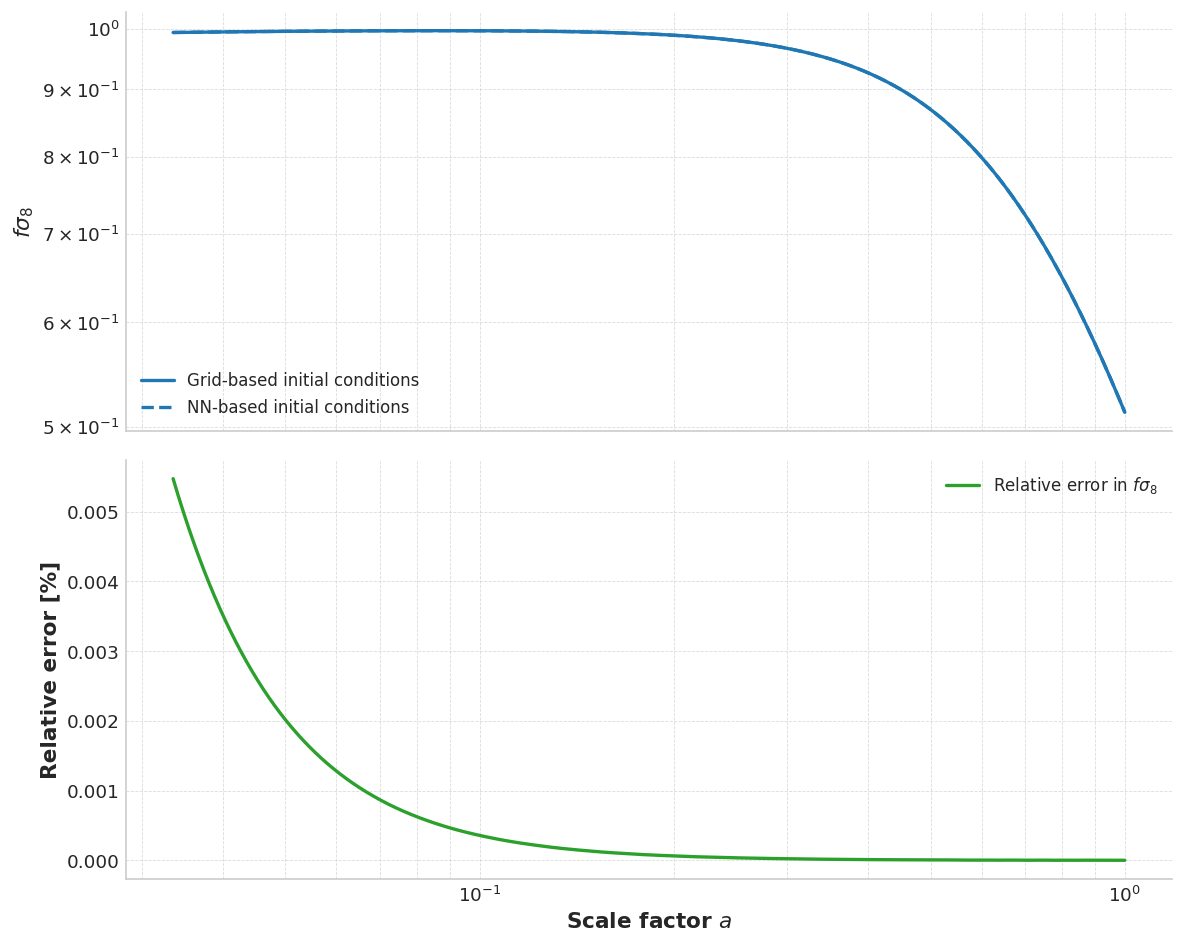

In [17]:
fsigma8_grid = a_nn * delta_prime_nn / delta_nn
fsigma8_nn = a_grid * delta_prime_grid / delta_grid
rel_error_fsigma8 = 100.0 * np.abs(fsigma8_grid - fsigma8_nn) / np.maximum(np.abs(fsigma8_nn), 1e-12)

fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax[0].plot(a_nn, fsigma8_grid, label='Grid-based initial conditions', color='tab:blue', linewidth=2)
ax[0].plot(a_grid, fsigma8_nn, label='NN-based initial conditions', color='tab:blue', linestyle='--', linewidth=2)
ax[0].set_ylabel(r'$f\sigma_8$', fontsize=13, fontweight='bold')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
ax[0].legend(frameon=False, fontsize=10, loc='best')

ax[1].plot(a_nn, rel_error_fsigma8, color='tab:green', linewidth=2, label='Relative error in $f\sigma_8$')
ax[1].set_xlabel('Scale factor $a$', fontsize=13, fontweight='bold')
ax[1].set_ylabel('Relative error [%]', fontsize=13, fontweight='bold')
ax[1].set_xscale('log')
ax[1].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
ax[1].legend(frameon=False, fontsize=10, loc='best')

plt.tight_layout()
plt.show()
